## 0) Import the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import set_config
set_config(transform_output="pandas")


## 1) Import the Data

In [4]:
dataset=pd.read_csv('housing.csv')

## 2) Take a Quick Look at the Data Structure

In [6]:
dataset.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [7]:
dataset.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
dataset["ocean_proximity"].value_counts()


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [10]:
dataset.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [11]:
dataset.describe(include=[object])

,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


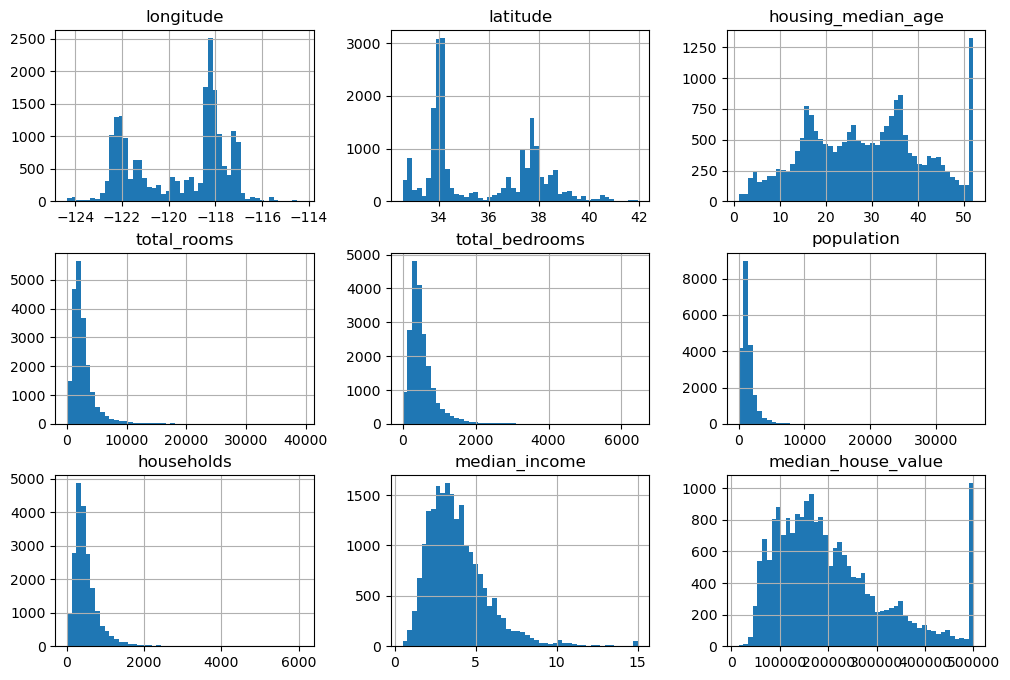

In [12]:
dataset.hist(bins=50, figsize=(12,8))
plt.show()

## 3) Split Data to train_set and test_set

In [14]:
dataset["income_cut"]=pd.cut(dataset["median_income"],
                             bins=[0,1.5,3,4.5,6,np.inf],
                             labels=[1,2,3,4,5])


In [15]:
dataset["median_income"]

0        8.3252
1        8.3014
2        7.2574
3        5.6431
4        3.8462
          ...  
20635    1.5603
20636    2.5568
20637    1.7000
20638    1.8672
20639    2.3886
Name: median_income, Length: 20640, dtype: float64

In [16]:
dataset["income_cut"]

0        5
1        5
2        5
3        4
4        3
        ..
20635    2
20636    2
20637    2
20638    2
20639    2
Name: income_cut, Length: 20640, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

In [17]:
from sklearn.model_selection import train_test_split
train_set,test_set=train_test_split(dataset,test_size=0.2,
                                    random_state=42)

In [18]:
a= train_set["income_cut"].value_counts() / len(train_set)
b= test_set["income_cut"].value_counts() / len(test_set)

df=pd.concat([a,b],axis=1)
df.columns=["X_train","X_test"]
df

,X_train,X_test
income_cut,,
3,0.351926,0.345203
2,0.321705,0.307413
4,0.174358,0.184109
5,0.112827,0.120882
1,0.039184,0.042393


In [19]:
from sklearn.model_selection import train_test_split

X=dataset.drop("median_house_value",axis=1)
y=dataset["median_house_value"]
X_train,X_test,y_train,y_test=train_test_split(X,y
                ,test_size=0.2
                                               )

#### with strat

In [21]:
dataset["income_cut"]=pd.cut(dataset["median_income"],
                             bins=[0,1.5,3,4.5,6,np.inf],
                             labels=[1,2,3,4,5])


In [22]:
X=dataset.drop("median_house_value",axis=1)
y=dataset["median_house_value"]
X_train,X_test,y_train,y_test=train_test_split(X,y,
    test_size=0.2,random_state=42,stratify=dataset["income_cut"])

In [23]:
a= X_train["income_cut"].value_counts() / len(train_set)
b= X_test["income_cut"].value_counts() / len(test_set)

df=pd.concat([a,b],axis=1)
df.columns=["X_train","X_test"]
df

,X_train,X_test
income_cut,,
3,0.350594,0.350533
2,0.318859,0.318798
4,0.176296,0.176357
5,0.114462,0.114341
1,0.039789,0.039971


In [24]:
X_train.drop("income_cut",axis=1,inplace=True)
X_test.drop("income_cut",axis=1,inplace=True)

## 4) Discover and Visualize the Data to Gain Insights

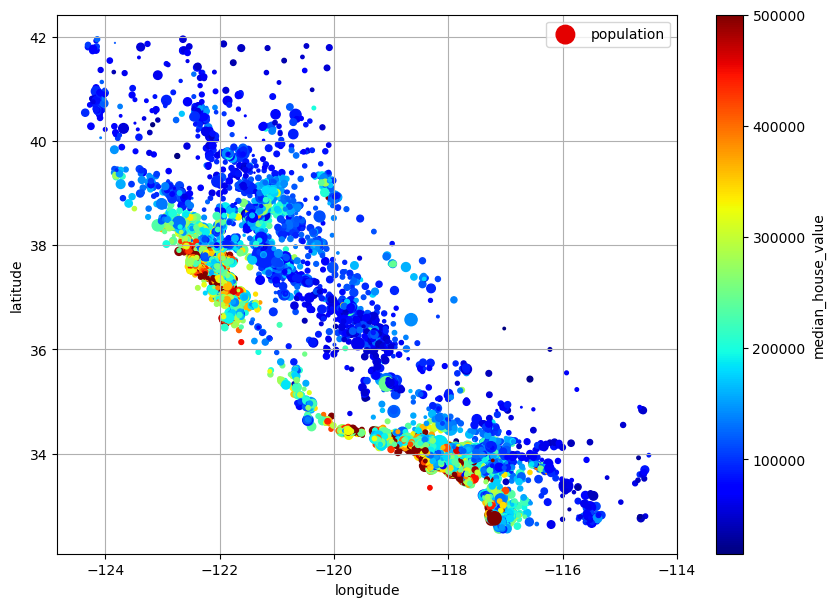

In [26]:
pd.concat([X_train,y_train],axis=1).plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=train_set["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
plt.show()

In [27]:
from IPython import display
display.Image("./images/california_housing_prices_plot.png")

FileNotFoundError: No such file or directory: './images/california_housing_prices_plot.png'

FileNotFoundError: No such file or directory: './images/california_housing_prices_plot.png'

<IPython.core.display.Image object>

## 5) Looking for Correlations

In [29]:
from IPython import display
display.Image("./images/Standard correlation coefficient.png")

FileNotFoundError: No such file or directory: './images/Standard correlation coefficient.png'

FileNotFoundError: No such file or directory: './images/Standard correlation coefficient.png'

<IPython.core.display.Image object>

In [30]:
corr_one=pd.concat([X_train,y_train],axis=1).corr(numeric_only=True)
corr_one["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

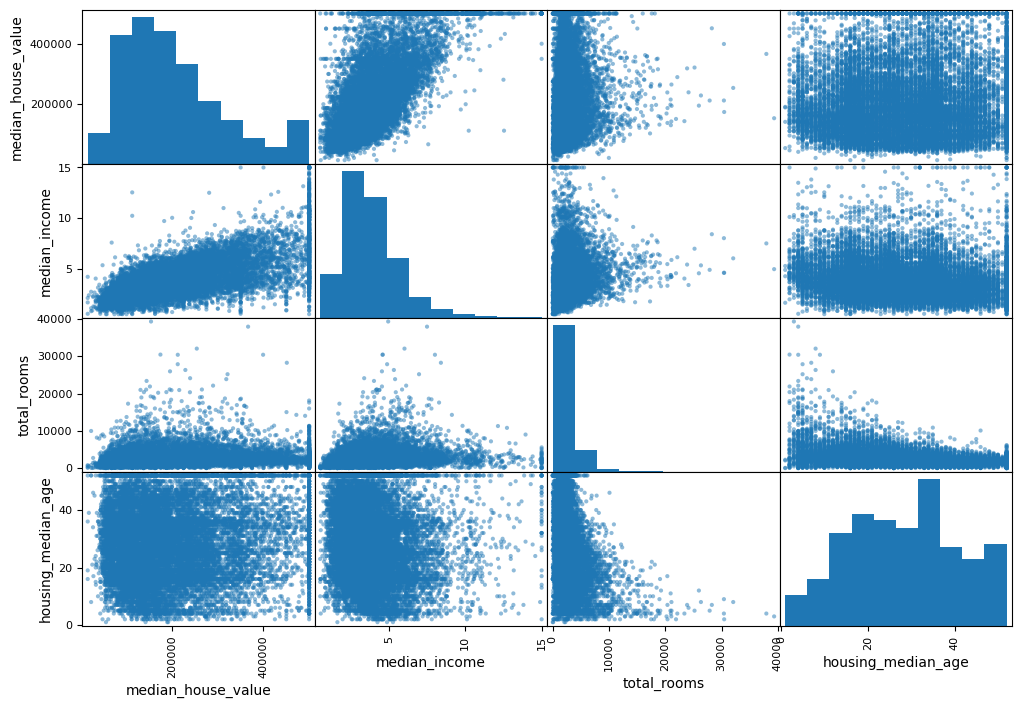

In [31]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]

data_to_show_corr=pd.concat([X_train,y_train],axis=1)
data_to_show_corr=data_to_show_corr[attributes]
scatter_matrix(data_to_show_corr,figsize=(12,8))
plt.show()

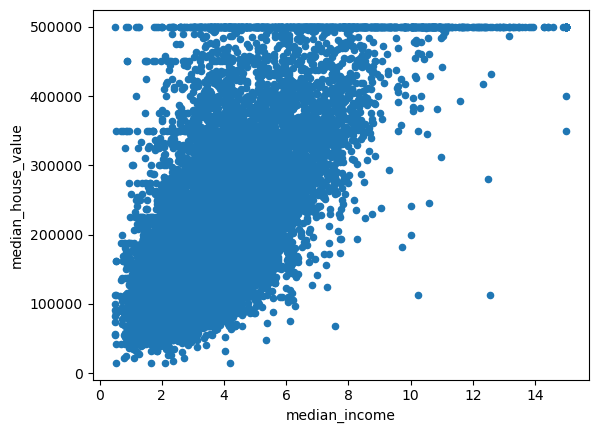

In [32]:
pd.concat([X_train,y_train],axis=1).plot(kind="scatter",x="median_income",y="median_house_value")

plt.show()

## 6) Experimenting with Attribute Combinations

In [127]:
dataset["rooms_per_house"]= dataset["total_rooms"] / dataset["households"]
dataset["bedrooms_ratio"] = dataset["total_bedrooms"] / dataset["total_rooms"]
dataset["people_per_house"] = dataset["population"] / dataset["households"]

In [129]:
corr_two = dataset.corr(numeric_only=True)
corr_two["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
rooms_per_house       0.151948
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
people_per_house     -0.023737
population           -0.024650
longitude            -0.045967
latitude             -0.144160
bedrooms_ratio       -0.255880
Name: median_house_value, dtype: float64

In [131]:
df=pd.concat([corr_one["median_house_value"],corr_two["median_house_value"]],axis=1)
df.columns=["corr_one","corr_two"]
df.sort_values(by=["corr_two"],ascending=False,inplace=True)

df

,corr_one,corr_two
median_house_value,1.000000,1.000000
median_income,0.688380,0.688075
rooms_per_house,NaN,0.151948
total_rooms,0.137455,0.134153
housing_median_age,0.102175,0.105623
households,0.071426,0.065843
total_bedrooms,0.054635,0.049686
people_per_house,NaN,-0.023737
population,-0.020153,-0.024650
longitude,-0.050859,-0.045967


## 7) Prepare the Data for Machine Learning Algorithms¶

### 7.0) Split dataset to number dataset and object dataset

In [135]:
train_set_num=X_train.select_dtypes(include=[np.number])
train_set_obj=X_train.select_dtypes(include=[object])

test_set_num=X_test.select_dtypes(include=[np.number])
test_set_obj=X_test.select_dtypes(include=[object])


In [137]:
train_set_obj

""
14973
3785
14689
20507
1286
...
14207
13105
19301
19121


### 7.1) Data Cleaning

In [148]:
train_set_num.isnull().any(axis=1).sum()

train_set_num.dropna(subset=["total_bedrooms"],inplace=False)  # option 1
train_set_num.drop("total_bedrooms", axis=1, inplace=False)  # option 2
train_set_num["total_bedrooms"].fillna(train_set_num["total_bedrooms"].median(), inplace=False)  # option 3

print()

In [150]:
print(train_set_num.isnull().any(axis=1).sum())

0


In [142]:
from sklearn.impute import SimpleImputer

imputer=SimpleImputer(strategy="median")

In [144]:
imputer.fit(train_set_num)

SimpleImputer(strategy='median')

In [146]:
imputer.statistics_

array([ 0.54881308, -0.64897998,  0.04224825, -0.18087645, -0.18303994,
       -0.18431123, -0.17959435, -0.1540771 ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ])

In [46]:
 train_set_num.median().values

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [47]:
imputer.statistics_ == train_set_num.median().values

array([ True,  True,  True,  True,  True,  True,  True,  True])

In [48]:
print("Before")
print("train_set_num sum of null values: ",train_set_num.isnull().sum().sum())
print("test_set_num sum of null values: ",test_set_num.isnull().sum().sum())
print("**********************")

train_set_num=imputer.transform(train_set_num)
test_set_num=imputer.transform(test_set_num)

print("**********************")
print("After")
print("train_set_num sum of null values: ",train_set_num.isnull().sum().sum())
print("test_set_num sum of null values: ",test_set_num.isnull().sum().sum())

Before
train_set_num sum of null values:  168
test_set_num sum of null values:  39
**********************
**********************
After
train_set_num sum of null values:  0
test_set_num sum of null values:  0


### 7.2) Remove Outliers

In [50]:
from sklearn.ensemble import IsolationForest

isolation_forest=IsolationForest(random_state=42)

outlier_pred= isolation_forest.fit(train_set_num)

train_outliers=isolation_forest.predict(train_set_num)
test_outliers=isolation_forest.predict(test_set_num)

print("ratio of outliers in train_set : ",(train_outliers==-1).sum()/len(train_outliers))


ratio of outliers in train_set :  0.125


In [51]:
train_set_num=train_set_num.iloc[train_outliers==1]
test_set_num=test_set_num.iloc[test_outliers==1]

## 7.3) Feature Scaling

In [53]:
from sklearn.preprocessing import MinMaxScaler

mm_scaler= MinMaxScaler(feature_range=(-1,1))
mm_scaler=mm_scaler.fit(train_set_num)

train_set_num_option1=mm_scaler.transform(train_set_num)
test_set_num_option1=mm_scaler.transform(test_set_num)


In [54]:
from sklearn.preprocessing import StandardScaler

std_scaler=StandardScaler()
std_scaler=std_scaler.fit(train_set_num)

train_set_num_option2=std_scaler.transform(train_set_num)
test_set_num_option2 =std_scaler.transform(test_set_num)

In [55]:
train_set_num=train_set_num_option2
test_set_num=test_set_num_option2

## 7.4) Handling Text and Categorical Attributes

In [57]:
train_set_obj.value_counts()

ocean_proximity
<1H OCEAN          7274
INLAND             5301
NEAR OCEAN         2089
NEAR BAY           1846
ISLAND                2
Name: count, dtype: int64

#### 7.4.1) OrdinalEncoder

In [59]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
ordinal_encoder = ordinal_encoder.fit(train_set_obj)

train_set_obj_option_1 = ordinal_encoder.transform(train_set_obj)
test_set_obj_option_1  = ordinal_encoder.transform(test_set_obj)

In [60]:
train_set_obj_option_1.head(5)

,ocean_proximity
13096,3.0
14973,0.0
3785,1.0
14689,1.0
20507,4.0


#### 7.4.2) OneHotEncoder

In [62]:
from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder(sparse_output=False)

onehot_encoder = onehot_encoder.fit(train_set_obj)

train_set_obj_option_2 = onehot_encoder.transform(train_set_obj)
test_set_obj_option_2 = onehot_encoder.transform(test_set_obj)

In [63]:
train_set_obj_option_2.head(3)

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
13096,0.0,0.0,0.0,1.0,0.0
14973,1.0,0.0,0.0,0.0,0.0
3785,0.0,1.0,0.0,0.0,0.0


In [64]:
train_set_obj=train_set_obj_option_2
test_set_obj=test_set_obj_option_2

In [65]:
train_set_obj

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
13096,0.0,0.0,0.0,1.0,0.0
14973,1.0,0.0,0.0,0.0,0.0
3785,0.0,1.0,0.0,0.0,0.0
14689,0.0,1.0,0.0,0.0,0.0
20507,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...
14207,1.0,0.0,0.0,0.0,0.0
13105,0.0,1.0,0.0,0.0,0.0
19301,0.0,0.0,0.0,0.0,1.0
19121,1.0,0.0,0.0,0.0,0.0


### 7.5) Merge the number dataset and the object dataset

In [67]:
X_train=pd.merge(train_set_num, train_set_obj, left_index=True, right_index=True)
X_test=pd.merge(test_set_num, test_set_obj, left_index=True, right_index=True)

In [68]:
X_train.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')

## 8) Train Model

In [70]:
from sklearn.linear_model import LinearRegression

y_train=y_train.loc[X_train.index]
y_test=y_test.loc[X_test.index]

model = LinearRegression()
model.fit(X_train,y_train)

some_new_data=X_test[:5]

a=y_test[:5].to_numpy()
b=model.predict(some_new_data)

pd.DataFrame([a,b,abs(a-b)],index=["Acutal","Predicted","ABS"]).T

,Acutal,Predicted,ABS
0,397700.0,398411.425318,711.425318
1,202900.0,250012.197765,47112.197765
2,314300.0,289116.753035,25183.246965
3,187500.0,239888.952155,52388.952155
4,141700.0,213159.380635,71459.380635


In [71]:
import sklearn.metrics as metrics
def regression_results(y_true, y_pred):

    # Regression metrics
    mean_absolute_error=metrics.mean_absolute_error(y_true, y_pred) 
    mse=metrics.mean_squared_error(y_true, y_pred) 
    median_absolute_error=metrics.median_absolute_error(y_true, y_pred)
    r2=metrics.r2_score(y_true, y_pred)

    print('r2: ', round(r2,4))
    print('MAE: ', round(mean_absolute_error,4))
    print('MSE: ', round(mse,4))
    print('RMSE: ', round(np.sqrt(mse),4))

In [72]:
regression_results(y_test,model.predict(X_test))

r2:  0.6576
MAE:  48040.1183
MSE:  4222951858.5515
RMSE:  64984.2432


In [ ]:
r2:  0.918
MAE:  744.2514
MSE:  1303023.567
RMSE:  1141.5006
regression_results(y_train,model.predict(X_train))
r2:  0.9201
MAE:  741.4419
MSE:  1272675.5493
RMSE:  1128.1292